# Подбор threshold для трех лучших embedding-классификаторов

Здесь я уже изучаю топ-3 модели с прошлого ноутбука и подбираю лучшие связки embedding-модель + классификатор и подбирает отдельный threshold для каждого класса.

## Зачем нужен ноутбук

На предыдущем этапе были протестированы разные embedding-модели и классификаторы.  
После сравнения были выбраны три лучшие связки:

```text
bge-m3 + LinearSVC_balanced
bge-m3 + SGD_hinge_balanced
USER-bge-m3 + Ridge_balanced
```

Цель этого ноутбука — проверить, улучшает ли качество отдельный порог принятия решения для каждого класса.

## Входные данные

```text
train dataset:
data/labeled/wb_feedbacks_ChatGpt_markup_from_synthetic_gpt5_V_2/
chatgpt_labeled_reviews_mvp_combined.csv
```

```text
golden set:
data/labeled/wb_feedbacks_manual_check_random_gpt5_prompt_test_v5/
manual_check_random_by_class_gpt5_relabelled.csv
```

## Что делает ноутбук

1. Загружает train dataset и golden set.
2. Строит или загружает из кэша эмбеддинги.
3. Обучает три выбранные связки моделей.
4. Сначала оценивает baseline-версию со стандартным порогом.
5. Затем подбирает отдельный threshold для каждого класса.
6. Сравнивает baseline и thresholded-версии.
7. Сохраняет метрики, обученные модели и подобранные thresholds.

## Используемые embedding-модели

```text
BAAI/bge-m3
deepvk/USER-bge-m3
```

Ссылки:

- https://huggingface.co/BAAI/bge-m3
- https://huggingface.co/deepvk/USER-bge-m3

## Используемые классификаторы

```text
LinearSVC_balanced
SGD_hinge_balanced
Ridge_balanced
```

## Выходные данные

```text
data/labeled/embedding_classifier_experiments/
```

Основные файлы:

```text
summary_metrics_selected_baseline.csv
per_class_metrics_selected_baseline.csv

summary_metrics_selected_thresholded.csv
per_class_metrics_selected_thresholded.csv

summary_metrics_selected_combined.csv
per_class_metrics_selected_combined.csv
```

Также сохраняются файлы с подобранными порогами:

```text
<model>__<classifier>__thresholds.csv
```

## Роль в пайплайне

```text
лучшие embedding-классификаторы
        ↓
embedding_classifier_selected_3_thresholds.ipynb
        ↓
baseline vs thresholded сравнение
        ↓
выбор финальной модели по macro_f1 / precision / recall
```

Этот этап нужен для финального улучшения качества классификатора за счет индивидуальных порогов по классам.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Если запускаешь в Colab / чистом окружении, раскомментируй установку.
# !pip -q install -U sentence-transformers scikit-learn pandas numpy matplotlib tqdm joblib

In [3]:
import ast
import gc
import json
import os
import re
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.metrics import classification_report, precision_recall_fscore_support
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Конфигурация

In [4]:
# === УКАЖИ СВОЙ ПУТЬ ===
# Если в твоем старом ноутбуке уже есть переменная labeled_dir, можно оставить как есть.
try:
    labeled_dir
except NameError:
    labeled_dir = "/content/drive/MyDrive/MLops_project/project/data/labeled"  # поменяй на свой путь

labeled_dir = Path(labeled_dir)

GOLDEN_PATH = labeled_dir / "wb_feedbacks_manual_check_random_gpt5_prompt_test_v5" / "manual_check_random_by_class_gpt5_relabelled.csv"
TRAIN_PATH = labeled_dir / "wb_feedbacks_ChatGpt_markup_from_synthetic_gpt5_V_2" / "chatgpt_labeled_reviews_mvp_combined.csv"

OUTPUT_DIR = labeled_dir / "embedding_classifier_experiments"
EMB_DIR = OUTPUT_DIR / "embeddings_cache"
MODEL_DIR = OUTPUT_DIR / "trained_classifiers"
PLOTS_DIR = OUTPUT_DIR / "plots"

for p in [OUTPUT_DIR, EMB_DIR, MODEL_DIR, PLOTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("GOLDEN_PATH:", GOLDEN_PATH)
print("TRAIN_PATH:", TRAIN_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

GOLDEN_PATH: /content/drive/MyDrive/MLops_project/project/data/labeled/wb_feedbacks_manual_check_random_gpt5_prompt_test_v5/manual_check_random_by_class_gpt5_relabelled.csv
TRAIN_PATH: /content/drive/MyDrive/MLops_project/project/data/labeled/wb_feedbacks_ChatGpt_markup_from_synthetic_gpt5_V_2/chatgpt_labeled_reviews_mvp_combined.csv
OUTPUT_DIR: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments


In [5]:
# Зафиксированные embedding-модели и классификаторы для финального эксперимента.
from sklearn.linear_model import RidgeClassifier, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

EMBEDDING_MODELS = {
    "bge-m3": "BAAI/bge-m3",
    "USER-bge-m3": "deepvk/USER-bge-m3",
}

CLASSIFIERS = {
    "LinearSVC_balanced": lambda: OneVsRestClassifier(
        LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        n_jobs=-1,
    ),

    "SGD_hinge_balanced": lambda: OneVsRestClassifier(
        SGDClassifier(
            loss="hinge",
            class_weight="balanced",
            max_iter=3000,
            tol=1e-4,
            random_state=RANDOM_STATE,
        ),
        n_jobs=-1,
    ),

    "Ridge_balanced": lambda: OneVsRestClassifier(
        RidgeClassifier(
            class_weight="balanced",
        ),
        n_jobs=-1,
    ),
}

# Запускаем только эти 3 связки.
SELECTED_EXPERIMENTS = [
    ("bge-m3", "LinearSVC_balanced"),
    ("bge-m3", "SGD_hinge_balanced"),
    ("USER-bge-m3", "Ridge_balanced"),
]

BATCH_SIZE = 64
NORMALIZE_EMBEDDINGS = True
DROP_EXACT_TRAIN_TEST_LEAKAGE = True

# OOF-подбор порогов.
N_SPLITS_THRESHOLD = 5
N_THRESHOLD_GRID = 201


## 2. Утилиты для чтения и нормализации labels

In [6]:
def read_csv_smart(path: Path) -> pd.DataFrame:
    """Читает csv с несколькими частыми кодировками."""
    encodings = ["utf-8", "utf-8-sig", "cp1251"]
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_error = e
    raise last_error


def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def parse_labels_cell(x):
    """Парсит labels из list / json / python-list-string / строки через ; | , ."""
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []

    if isinstance(x, (list, tuple, set)):
        raw = list(x)
    else:
        s = str(x).strip()
        if not s or s.lower() in {"nan", "none", "null", "[]"}:
            return []

        parsed = None
        if s.startswith("[") or s.startswith("{"):
            for parser in (json.loads, ast.literal_eval):
                try:
                    parsed = parser(s)
                    break
                except Exception:
                    pass

        if isinstance(parsed, dict):
            # На случай формата {"labels": [...]}.
            if "labels" in parsed:
                raw = parsed["labels"]
            elif "new_labels" in parsed:
                raw = parsed["new_labels"]
            else:
                raw = list(parsed.values())
        elif isinstance(parsed, (list, tuple, set)):
            raw = list(parsed)
        elif parsed is not None:
            raw = [parsed]
        else:
            # fallback для строк вида: label1; label2 или label1 | label2
            if ";" in s:
                raw = s.split(";")
            elif "|" in s:
                raw = s.split("|")
            elif "," in s and not (s.startswith("[") and s.endswith("]")):
                raw = s.split(",")
            else:
                raw = [s]

    labels = []
    for item in raw:
        if item is None or (isinstance(item, float) and pd.isna(item)):
            continue
        label = str(item).strip().strip('"').strip("'").strip()
        if label and label.lower() not in {"nan", "none", "null"}:
            labels.append(label)

    # Убираем дубли, сохраняя порядок.
    return list(dict.fromkeys(labels))


def find_column(df, candidates, required=True):
    """Ищет колонку по списку возможных названий."""
    lower_map = {str(c).lower().strip(): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().strip()
        if key in lower_map:
            return lower_map[key]
    if required:
        raise ValueError(f"Не нашел колонку. Кандидаты: {candidates}. Есть колонки: {list(df.columns)}")
    return None


def safe_name(s: str) -> str:
    return re.sub(r"[^a-zA-Z0-9а-яА-Я_-]+", "_", s).strip("_")

## 3. Загрузка train и golden set

In [7]:
train_df = read_csv_smart(TRAIN_PATH)
golden_df = read_csv_smart(GOLDEN_PATH)

print("Train shape:", train_df.shape)
print("Golden shape:", golden_df.shape)
print("Train columns:", list(train_df.columns))
print("Golden columns:", list(golden_df.columns))

Train shape: (1820, 9)
Golden shape: (150, 17)
Train columns: ['отзыв', 'old_labels', 'new_labels', 'labels', 'source_type', 'source_files', 'source_row_ids', 'old_labels_str', 'new_labels_str']
Golden columns: ['manual_check_id', 'class_for_check', 'source_type', 'отзыв', 'old_labels', 'new_labels', 'correct_labels', 'old_labels_str', 'new_labels_str', 'correct_labels_str', 'labels_changed', 'new_equals_correct', 'comment', 'source_class_file', 'labels', 'labels_str', 'is_correct']


In [8]:
# Golden set: строго по твоему описанию — колонки 'отзыв', 'new_labels'.
GOLDEN_TEXT_COL = "отзыв"
GOLDEN_LABEL_COL = "new_labels"

if GOLDEN_TEXT_COL not in golden_df.columns:
    raise ValueError(f"В golden set нет колонки {GOLDEN_TEXT_COL!r}. Есть: {list(golden_df.columns)}")
if GOLDEN_LABEL_COL not in golden_df.columns:
    raise ValueError(f"В golden set нет колонки {GOLDEN_LABEL_COL!r}. Есть: {list(golden_df.columns)}")

# Train: ожидаем 'отзыв' и 'labels', но делаем fallback на частые варианты.
TRAIN_TEXT_COL = find_column(train_df, ["отзыв", "review", "review_text", "text", "feedback", "comment"])
TRAIN_LABEL_COL = find_column(train_df, ["labels", "new_labels", "label", "target", "classes"])

print("TRAIN_TEXT_COL:", TRAIN_TEXT_COL)
print("TRAIN_LABEL_COL:", TRAIN_LABEL_COL)
print("GOLDEN_TEXT_COL:", GOLDEN_TEXT_COL)
print("GOLDEN_LABEL_COL:", GOLDEN_LABEL_COL)

TRAIN_TEXT_COL: отзыв
TRAIN_LABEL_COL: labels
GOLDEN_TEXT_COL: отзыв
GOLDEN_LABEL_COL: new_labels


In [9]:
train = train_df[[TRAIN_TEXT_COL, TRAIN_LABEL_COL]].copy()
train.columns = ["text", "labels"]
train["text"] = train["text"].map(normalize_text)
train["labels"] = train["labels"].map(parse_labels_cell)
train = train[(train["text"] != "") & (train["labels"].map(len) > 0)].copy()

golden = golden_df[[GOLDEN_TEXT_COL, GOLDEN_LABEL_COL]].copy()
golden.columns = ["text", "labels"]
golden["text"] = golden["text"].map(normalize_text)
golden["labels"] = golden["labels"].map(parse_labels_cell)
golden = golden[(golden["text"] != "") & (golden["labels"].map(len) > 0)].copy()

# Убираем точные дубли внутри train и golden.
train = train.drop_duplicates(subset=["text"]).reset_index(drop=True)
golden = golden.drop_duplicates(subset=["text"]).reset_index(drop=True)

# Важно: если golden попал в train, это утечка. По умолчанию удаляем exact match из train.
if DROP_EXACT_TRAIN_TEST_LEAKAGE:
    golden_texts = set(golden["text"])
    before = len(train)
    train = train[~train["text"].isin(golden_texts)].reset_index(drop=True)
    print(f"Удалено exact-overlap из train по тексту: {before - len(train)}")

print("Train after cleaning:", train.shape)
print("Golden after cleaning:", golden.shape)

train.head()

Удалено exact-overlap из train по тексту: 87
Train after cleaning: (1733, 2)
Golden after cleaning: (147, 2)


,text,labels
0,Не держится. Какая то пленка …,[Проблема с качеством товара]
1,"Куртка хорошая, качественная! Замок правда зли...",[Проблема с качеством товара]
2,"Задумка не плохая, но качество материала не по...",[Проблема с качеством товара]
3,"Остаются темные потеки от конденсата,которые н...",[Проблема с качеством товара]
4,"К сожалению, пришли разбитые. Поэтому отказ",[Проблема с качеством товара]


In [10]:
all_labels = sorted(set(label for labels in pd.concat([train["labels"], golden["labels"]]) for label in labels))
print("Всего классов:", len(all_labels))
for i, label in enumerate(all_labels, 1):
    print(f"{i:02d}. {label}")

mlb = MultiLabelBinarizer(classes=all_labels)
Y_train = mlb.fit_transform(train["labels"])
Y_golden = mlb.transform(golden["labels"])

label_names = list(mlb.classes_)

train_counts = pd.Series(Y_train.sum(axis=0), index=label_names).sort_values(ascending=False)
golden_counts = pd.Series(Y_golden.sum(axis=0), index=label_names).sort_values(ascending=False)

counts_df = pd.DataFrame({
    "train_support": train_counts,
    "golden_support": golden_counts,
}).fillna(0).astype(int)

counts_df

Всего классов: 9
01. Другая проблема
02. Несоответствие карточке товара
03. Положительный / нейтральный отзыв
04. Проблема доставки / получения
05. Проблема с возвратом
06. Проблема с качеством товара
07. Проблема с комплектацией / упаковкой
08. Проблема с размером / посадкой
09. Цена / ценность


,train_support,golden_support
Другая проблема,66,5
Несоответствие карточке товара,231,32
Положительный / нейтральный отзыв,201,21
Проблема доставки / получения,205,18
Проблема с возвратом,230,21
Проблема с качеством товара,598,43
Проблема с комплектацией / упаковкой,421,24
Проблема с размером / посадкой,210,23
Цена / ценность,183,17


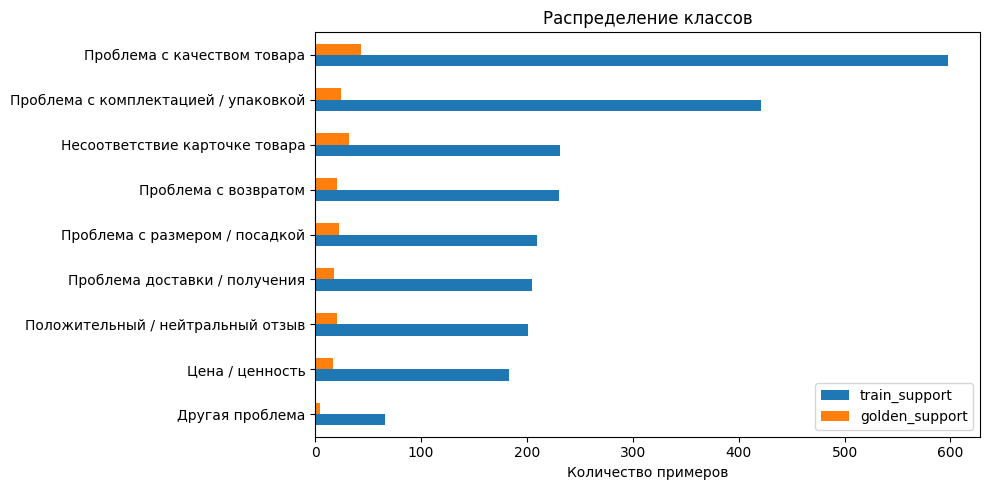

In [11]:
# Быстрый график распределения классов в train и golden.
ax = counts_df.sort_values("train_support", ascending=True).plot(
    kind="barh", figsize=(10, max(5, 0.35 * len(counts_df))), title="Распределение классов"
)
ax.set_xlabel("Количество примеров")
plt.tight_layout()
plt.show()

## 4. Расчет embeddings с кешированием

In [12]:
def get_embeddings(model_key: str, model_name: str, texts, batch_size=64, normalize=True):
    """Считает embeddings и кеширует их в .npy."""
    from sentence_transformers import SentenceTransformer
    import torch

    cache_path = EMB_DIR / f"{safe_name(model_key)}__n{len(texts)}__norm{int(normalize)}.npy"
    if cache_path.exists():
        print(f"Загружаю embeddings из кеша: {cache_path}")
        return np.load(cache_path)

    print(f"Считаю embeddings: {model_key} -> {model_name}")
    model = SentenceTransformer(model_name)
    embeddings = model.encode(
        list(texts),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=normalize,
    )
    embeddings = embeddings.astype("float32")
    np.save(cache_path, embeddings)
    print(f"Сохранил embeddings: {cache_path}")

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return embeddings

## 5. Обучение, baseline-оценка и подбор thresholds

Для каждой из 3 связок считаем:

1. baseline через стандартный `clf.predict()`;
2. thresholded-версию: отдельный порог для каждого класса, подобранный по OOF-предсказаниям на train.


In [13]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score


def evaluate_predictions(y_true, y_pred, label_names, model_key, classifier_key):
    """Возвращает per-class метрики и aggregate-метрики."""
    p, r, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        zero_division=0,
    )

    per_class = pd.DataFrame({
        "embedding_model": model_key,
        "classifier": classifier_key,
        "class": label_names,
        "precision": p,
        "recall": r,
        "f1": f1,
        "support": support,
        "true_rate_golden": np.asarray(y_true).mean(axis=0),
        "predicted_rate_golden": np.asarray(y_pred).mean(axis=0),
    })

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="micro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    summary = {
        "embedding_model": model_key,
        "classifier": classifier_key,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "micro_precision": micro_p,
        "micro_recall": micro_r,
        "micro_f1": micro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
    }
    return per_class, summary


def get_X_train_X_golden(model_key, model_name):
    """Загружает/считает embeddings и возвращает X_train, X_golden."""
    all_texts = pd.concat([train["text"], golden["text"]], ignore_index=True)
    all_embeddings = get_embeddings(
        model_key=model_key,
        model_name=model_name,
        texts=all_texts,
        batch_size=BATCH_SIZE,
        normalize=NORMALIZE_EMBEDDINGS,
    )

    X_train = all_embeddings[:len(train)]
    X_golden = all_embeddings[len(train):]
    return X_train, X_golden


def get_model_scores(clf, X):
    """
    Возвращает score для каждого класса.

    Для LinearSVC / SGD_hinge / Ridge это decision_function.
    Это не вероятность, но threshold по таким score подбирать можно.
    """
    if hasattr(clf, "decision_function"):
        scores = clf.decision_function(X)
    elif hasattr(clf, "predict_proba"):
        proba = clf.predict_proba(X)
        if isinstance(proba, list):
            scores = np.column_stack([p[:, 1] for p in proba])
        else:
            scores = proba
    else:
        raise ValueError("У классификатора нет decision_function или predict_proba")

    scores = np.asarray(scores)
    if scores.ndim == 1:
        scores = scores.reshape(-1, 1)
    return scores


def find_best_thresholds(y_true, scores, label_names, n_grid=201):
    """Подбирает отдельный threshold для каждого класса по максимуму F1 на OOF-score."""
    thresholds = []
    rows = []

    for j, class_name in enumerate(label_names):
        y_j = y_true[:, j]
        s_j = scores[:, j]

        if y_j.sum() == 0:
            best_t = 0.0
            best_f1 = 0.0
            pred_rate = 0.0
        else:
            # Для линейных моделей стандартный threshold обычно 0.
            # Но для каждого класса ищем более подходящий порог.
            if np.isclose(s_j.min(), s_j.max()):
                grid = np.array([s_j.min()])
            else:
                grid = np.linspace(s_j.min(), s_j.max(), n_grid)

            best_t = 0.0
            best_f1 = -1.0
            pred_rate = 0.0

            for t in grid:
                pred_j = (s_j >= t).astype(int)
                cur_f1 = f1_score(y_j, pred_j, zero_division=0)

                if cur_f1 > best_f1:
                    best_f1 = cur_f1
                    best_t = float(t)
                    pred_rate = float(pred_j.mean())

        thresholds.append(best_t)
        rows.append({
            "class": class_name,
            "best_threshold": best_t,
            "oof_f1_at_threshold": best_f1,
            "support_train": int(y_j.sum()),
            "true_rate_train": float(y_j.mean()),
            "predicted_rate_oof_at_threshold": pred_rate,
        })

    thresholds = np.array(thresholds, dtype=float)
    thresholds_df = pd.DataFrame(rows)
    return thresholds, thresholds_df


def predict_with_thresholds(scores, thresholds):
    """Превращает scores в multi-label prediction по отдельным thresholds."""
    return (scores >= thresholds.reshape(1, -1)).astype(int)


def run_single_experiment_baseline(model_key, model_name, classifier_key, classifier_factory):
    print("=" * 100)
    print(f"BASELINE | Embedding model: {model_key} | Classifier: {classifier_key}")

    X_train, X_golden = get_X_train_X_golden(model_key, model_name)

    clf = classifier_factory()
    clf.fit(X_train, Y_train)
    y_pred = clf.predict(X_golden)

    per_class, summary = evaluate_predictions(
        Y_golden,
        y_pred,
        label_names=label_names,
        model_key=model_key,
        classifier_key=classifier_key + "__baseline",
    )

    summary["threshold_tuning"] = "none"
    summary["n_splits"] = 0

    model_path = MODEL_DIR / f"{safe_name(model_key)}__{safe_name(classifier_key)}__baseline.joblib"
    joblib.dump(clf, model_path)
    print("Saved baseline classifier:", model_path)
    print("Macro F1:", round(summary["macro_f1"], 4))

    return per_class, summary


def run_single_experiment_with_thresholds(
    model_key,
    model_name,
    classifier_key,
    classifier_factory,
    n_splits=5,
    n_grid=201,
):
    print("=" * 100)
    print(f"THRESHOLDS | Embedding model: {model_key} | Classifier: {classifier_key}")

    X_train, X_golden = get_X_train_X_golden(model_key, model_name)

    # 1. OOF scores на train для честного подбора thresholds.
    oof_scores = np.zeros_like(Y_train, dtype=float)

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train), start=1):
        print(f"OOF fold {fold}/{n_splits}")
        clf_fold = classifier_factory()
        clf_fold.fit(X_train[tr_idx], Y_train[tr_idx])
        oof_scores[val_idx] = get_model_scores(clf_fold, X_train[val_idx])

    # 2. Подбор thresholds по OOF scores.
    thresholds, thresholds_df = find_best_thresholds(
        y_true=Y_train,
        scores=oof_scores,
        label_names=label_names,
        n_grid=n_grid,
    )

    # 3. Финальная модель на всём train.
    final_clf = classifier_factory()
    final_clf.fit(X_train, Y_train)

    # 4. Golden set — только финальная проверка.
    golden_scores = get_model_scores(final_clf, X_golden)
    y_pred_thresholded = predict_with_thresholds(golden_scores, thresholds)

    per_class, summary = evaluate_predictions(
        Y_golden,
        y_pred_thresholded,
        label_names=label_names,
        model_key=model_key,
        classifier_key=classifier_key + "__thresholded",
    )

    per_class = per_class.merge(
        thresholds_df[[
            "class",
            "best_threshold",
            "oof_f1_at_threshold",
            "support_train",
            "true_rate_train",
            "predicted_rate_oof_at_threshold",
        ]],
        on="class",
        how="left",
    )

    summary["threshold_tuning"] = "oof_per_class_f1"
    summary["n_splits"] = n_splits

    # 5. Сохраняем модель и thresholds.
    model_path = MODEL_DIR / f"{safe_name(model_key)}__{safe_name(classifier_key)}__thresholded.joblib"
    thresholds_path = OUTPUT_DIR / f"{safe_name(model_key)}__{safe_name(classifier_key)}__thresholds.csv"

    joblib.dump(
        {
            "model": final_clf,
            "thresholds": thresholds,
            "label_names": label_names,
            "model_key": model_key,
            "classifier_key": classifier_key,
            "threshold_tuning": "oof_per_class_f1",
        },
        model_path,
    )

    thresholds_df.to_csv(thresholds_path, index=False, encoding="utf-8-sig")

    print("Saved thresholded model:", model_path)
    print("Saved thresholds:", thresholds_path)
    print("Macro F1:", round(summary["macro_f1"], 4))

    return per_class, summary


In [14]:
all_per_class_baseline = []
all_summary_baseline = []
all_per_class_thresholded = []
all_summary_thresholded = []

for model_key, classifier_key in SELECTED_EXPERIMENTS:
    model_name = EMBEDDING_MODELS[model_key]
    classifier_factory = CLASSIFIERS[classifier_key]

    per_class_df, summary_dict = run_single_experiment_baseline(
        model_key=model_key,
        model_name=model_name,
        classifier_key=classifier_key,
        classifier_factory=classifier_factory,
    )
    all_per_class_baseline.append(per_class_df)
    all_summary_baseline.append(summary_dict)

    per_class_df_thr, summary_dict_thr = run_single_experiment_with_thresholds(
        model_key=model_key,
        model_name=model_name,
        classifier_key=classifier_key,
        classifier_factory=classifier_factory,
        n_splits=N_SPLITS_THRESHOLD,
        n_grid=N_THRESHOLD_GRID,
    )
    all_per_class_thresholded.append(per_class_df_thr)
    all_summary_thresholded.append(summary_dict_thr)

per_class_metrics_baseline = pd.concat(all_per_class_baseline, ignore_index=True)
summary_metrics_baseline = pd.DataFrame(all_summary_baseline)

per_class_metrics_thresholded = pd.concat(all_per_class_thresholded, ignore_index=True)
summary_metrics_thresholded = pd.DataFrame(all_summary_thresholded)

# Общие таблицы для просмотра/графиков ниже.
per_class_metrics = pd.concat(
    [per_class_metrics_baseline, per_class_metrics_thresholded],
    ignore_index=True,
)
summary_metrics = pd.concat(
    [summary_metrics_baseline, summary_metrics_thresholded],
    ignore_index=True,
)

paths = {
    "per_class_baseline": OUTPUT_DIR / "per_class_metrics_selected_baseline.csv",
    "summary_baseline": OUTPUT_DIR / "summary_metrics_selected_baseline.csv",
    "per_class_thresholded": OUTPUT_DIR / "per_class_metrics_selected_thresholded.csv",
    "summary_thresholded": OUTPUT_DIR / "summary_metrics_selected_thresholded.csv",
    "per_class_combined": OUTPUT_DIR / "per_class_metrics_selected_combined.csv",
    "summary_combined": OUTPUT_DIR / "summary_metrics_selected_combined.csv",
}

per_class_metrics_baseline.to_csv(paths["per_class_baseline"], index=False, encoding="utf-8-sig")
summary_metrics_baseline.to_csv(paths["summary_baseline"], index=False, encoding="utf-8-sig")
per_class_metrics_thresholded.to_csv(paths["per_class_thresholded"], index=False, encoding="utf-8-sig")
summary_metrics_thresholded.to_csv(paths["summary_thresholded"], index=False, encoding="utf-8-sig")
per_class_metrics.to_csv(paths["per_class_combined"], index=False, encoding="utf-8-sig")
summary_metrics.to_csv(paths["summary_combined"], index=False, encoding="utf-8-sig")

for name, path in paths.items():
    print(f"Saved {name}:", path)


BASELINE | Embedding model: bge-m3 | Classifier: LinearSVC_balanced
Загружаю embeddings из кеша: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/embeddings_cache/bge-m3__n1880__norm1.npy
Saved baseline classifier: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/trained_classifiers/bge-m3__LinearSVC_balanced__baseline.joblib
Macro F1: 0.8134
THRESHOLDS | Embedding model: bge-m3 | Classifier: LinearSVC_balanced
Загружаю embeddings из кеша: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/embeddings_cache/bge-m3__n1880__norm1.npy
OOF fold 1/5
OOF fold 2/5
OOF fold 3/5
OOF fold 4/5
OOF fold 5/5
Saved thresholded model: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/trained_classifiers/bge-m3__LinearSVC_balanced__thresholded.joblib
Saved thresholds: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_class

## 6. Итоговая таблица метрик

В таблице ниже есть baseline и thresholded-версии для 3 выбранных связок.


In [15]:
summary_metrics_sorted = summary_metrics.sort_values("macro_f1", ascending=False).reset_index(drop=True)
summary_metrics_sorted

,embedding_model,classifier,macro_precision,macro_recall,macro_f1,micro_precision,micro_recall,micro_f1,weighted_precision,weighted_recall,weighted_f1,threshold_tuning,n_splits
0,bge-m3,LinearSVC_balanced__thresholded,0.820325,0.832689,0.822103,0.805556,0.852941,0.828571,0.814592,0.852941,0.828510,oof_per_class_f1,5
1,bge-m3,LinearSVC_balanced__baseline,0.768141,0.877154,0.813398,0.779221,0.882353,0.827586,0.789601,0.882353,0.830185,none,0
2,USER-bge-m3,Ridge_balanced__thresholded,0.824596,0.815427,0.812645,0.805687,0.833333,0.819277,0.822435,0.833333,0.819609,oof_per_class_f1,5
3,bge-m3,SGD_hinge_balanced__baseline,0.760692,0.878662,0.806388,0.781659,0.877451,0.826790,0.797510,0.877451,0.831447,none,0
4,bge-m3,SGD_hinge_balanced__thresholded,0.793675,0.829031,0.803242,0.811321,0.843137,0.826923,0.829531,0.843137,0.831571,oof_per_class_f1,5
5,USER-bge-m3,Ridge_balanced__baseline,0.734463,0.909183,0.802490,0.750000,0.897059,0.816964,0.764375,0.897059,0.821002,none,0


In [16]:
# Быстрое сравнение baseline vs thresholded по macro_f1.
comparison = summary_metrics.copy()
comparison["base_classifier"] = comparison["classifier"].str.replace("__baseline", "", regex=False).str.replace("__thresholded", "", regex=False)
comparison["version"] = np.where(comparison["classifier"].str.contains("thresholded"), "thresholded", "baseline")

comparison_pivot = comparison.pivot_table(
    index=["embedding_model", "base_classifier"],
    columns="version",
    values=["macro_precision", "macro_recall", "macro_f1", "micro_f1", "weighted_f1"],
)
comparison_pivot


macro_f1             macro_precision  \
version                             baseline thresholded        baseline   
embedding_model base_classifier                                            
USER-bge-m3     Ridge_balanced      0.802490    0.812645        0.734463   
bge-m3          LinearSVC_balanced  0.813398    0.822103        0.768141   
                SGD_hinge_balanced  0.806388    0.803242        0.760692   

                                               macro_recall              \
version                            thresholded     baseline thresholded   
embedding_model base_classifier                                           
USER-bge-m3     Ridge_balanced        0.824596     0.909183    0.815427   
bge-m3          LinearSVC_balanced    0.820325     0.877154    0.832689   
                SGD_hinge_balanced    0.793675     0.878662    0.829031   

                                    micro_f1             weighted_f1  \
version                             baseline thresholded    baseline   
embedding_model base_classifier                                        
USER-bge-m3     Ridge_balanced      0.816964    0.819277    0.821002   
bge-m3          LinearSVC_balanced  0.827586    0.828571    0.830185   
                SGD_hinge_balanced  0.826790    0.826923    0.831447   

                                                
version                            thresholded  
embedding_model base_classifier                 
USER-bge-m3     Ridge_balanced        0.819609  
bge-m3          LinearSVC_balanced    0.828510  
                SGD_hinge_balanced    0.831571

In [17]:
# Таблица per-class метрик для всех экспериментов.
per_class_metrics.sort_values(["class", "f1"], ascending=[True, False]).reset_index(drop=True)

,embedding_model,classifier,class,precision,recall,f1,support,true_rate_golden,predicted_rate_golden,best_threshold,oof_f1_at_threshold,support_train,true_rate_train,predicted_rate_oof_at_threshold
0,bge-m3,LinearSVC_balanced__thresholded,Другая проблема,0.750000,0.600000,0.666667,5,0.034014,0.027211,0.288655,0.493506,66.0,0.038084,0.050779
1,USER-bge-m3,Ridge_balanced__thresholded,Другая проблема,0.750000,0.600000,0.666667,5,0.034014,0.027211,0.266660,0.491018,66.0,0.038084,0.058280
2,USER-bge-m3,Ridge_balanced__baseline,Другая проблема,0.416667,1.000000,0.588235,5,0.034014,0.081633,NaN,NaN,NaN,NaN,NaN
3,bge-m3,LinearSVC_balanced__baseline,Другая проблема,0.444444,0.800000,0.571429,5,0.034014,0.061224,NaN,NaN,NaN,NaN,NaN
4,bge-m3,SGD_hinge_balanced__baseline,Другая проблема,0.363636,0.800000,0.500000,5,0.034014,0.074830,NaN,NaN,NaN,NaN,NaN
5,bge-m3,SGD_hinge_balanced__thresholded,Другая проблема,0.333333,0.600000,0.428571,5,0.034014,0.061224,0.080008,0.487179,66.0,0.038084,0.051933
6,USER-bge-m3,Ridge_balanced__baseline,Несоответствие карточке товара,0.866667,0.812500,0.838710,32,0.217687,0.204082,NaN,NaN,NaN,NaN,NaN
7,bge-m3,LinearSVC_balanced__baseline,Несоответствие карточке товара,0.806452,0.781250,0.793651,32,0.217687,0.210884,NaN,NaN,NaN,NaN,NaN
8,bge-m3,SGD_hinge_balanced__baseline,Несоответствие карточке товара,0.781250,0.781250,0.781250,32,0.217687,0.217687,NaN,NaN,NaN,NaN,NaN
9,bge-m3,SGD_hinge_balanced__thresholded,Несоответствие карточке товара,0.821429,0.718750,0.766667,32,0.217687,0.190476,0.628936,0.712589,231.0,0.133295,0.109636


In [18]:
# Удобная сводная таблица F1 по классам: строки — классы, колонки — эксперименты.
per_class_metrics["experiment"] = per_class_metrics["embedding_model"] + " + " + per_class_metrics["classifier"]
f1_pivot = per_class_metrics.pivot_table(index="class", columns="experiment", values="f1")
recall_pivot = per_class_metrics.pivot_table(index="class", columns="experiment", values="recall")
precision_pivot = per_class_metrics.pivot_table(index="class", columns="experiment", values="precision")

f1_pivot

experiment,USER-bge-m3 + Ridge_balanced__baseline,USER-bge-m3 + Ridge_balanced__thresholded,bge-m3 + LinearSVC_balanced__baseline,bge-m3 + LinearSVC_balanced__thresholded,bge-m3 + SGD_hinge_balanced__baseline,bge-m3 + SGD_hinge_balanced__thresholded
class,,,,,,
Другая проблема,0.588235,0.666667,0.571429,0.666667,0.500000,0.428571
Несоответствие карточке товара,0.838710,0.763636,0.793651,0.758621,0.781250,0.766667
Положительный / нейтральный отзыв,0.818182,0.900000,0.878049,0.878049,0.878049,0.900000
Проблема доставки / получения,0.789474,0.848485,0.833333,0.857143,0.833333,0.848485
Проблема с возвратом,0.893617,0.888889,0.893617,0.909091,0.857143,0.933333
Проблема с качеством товара,0.804124,0.791667,0.804124,0.795918,0.818182,0.808989
Проблема с комплектацией / упаковкой,0.750000,0.763636,0.754717,0.754717,0.800000,0.777778
Проблема с размером / посадкой,0.897959,0.913043,0.958333,0.978723,0.978723,0.954545
Цена / ценность,0.842105,0.777778,0.833333,0.800000,0.810811,0.810811


## 7. Графики

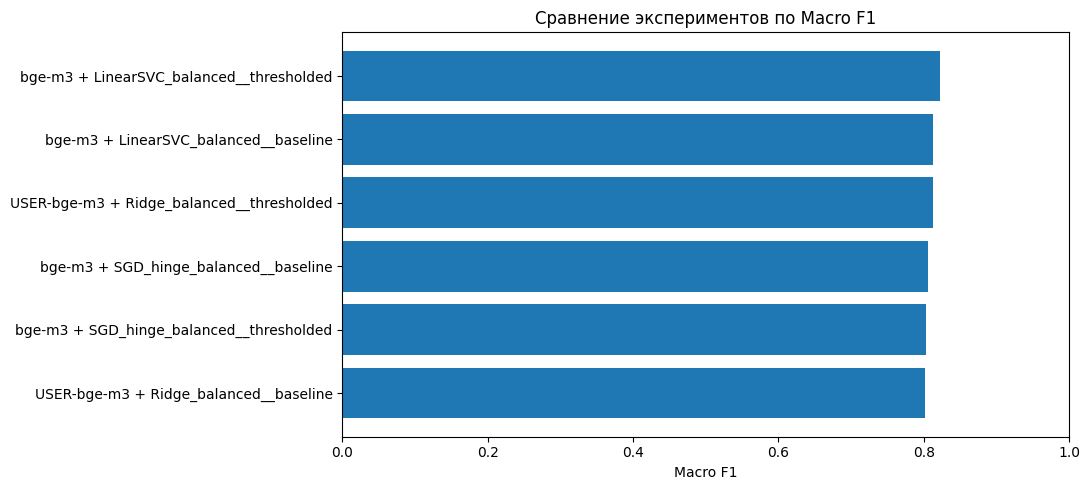

In [19]:
# График 1: macro F1 по экспериментам.
plot_df = summary_metrics_sorted.copy()
plot_df["experiment"] = plot_df["embedding_model"] + " + " + plot_df["classifier"]
plot_df = plot_df.sort_values("macro_f1", ascending=True)

plt.figure(figsize=(11, max(5, 0.55 * len(plot_df))))
plt.barh(plot_df["experiment"], plot_df["macro_f1"])
plt.xlabel("Macro F1")
plt.title("Сравнение экспериментов по Macro F1")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "macro_f1_by_experiment.png", dpi=200, bbox_inches="tight")
plt.show()

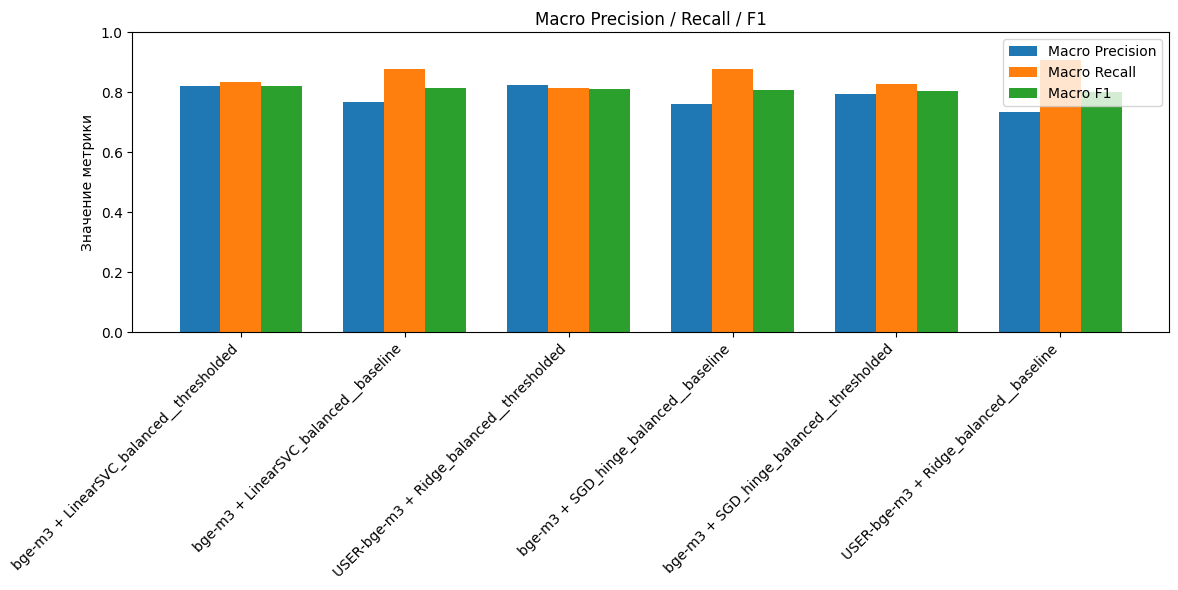

In [20]:
# График 2: macro precision / recall / F1 по экспериментам.
plot_df = summary_metrics_sorted.copy()
plot_df["experiment"] = plot_df["embedding_model"] + " + " + plot_df["classifier"]
plot_df = plot_df.sort_values("macro_f1", ascending=False)

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(max(12, 1.2 * len(plot_df)), 6))
plt.bar(x - width, plot_df["macro_precision"], width, label="Macro Precision")
plt.bar(x, plot_df["macro_recall"], width, label="Macro Recall")
plt.bar(x + width, plot_df["macro_f1"], width, label="Macro F1")
plt.xticks(x, plot_df["experiment"], rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel("Значение метрики")
plt.title("Macro Precision / Recall / F1")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "macro_precision_recall_f1.png", dpi=200, bbox_inches="tight")
plt.show()

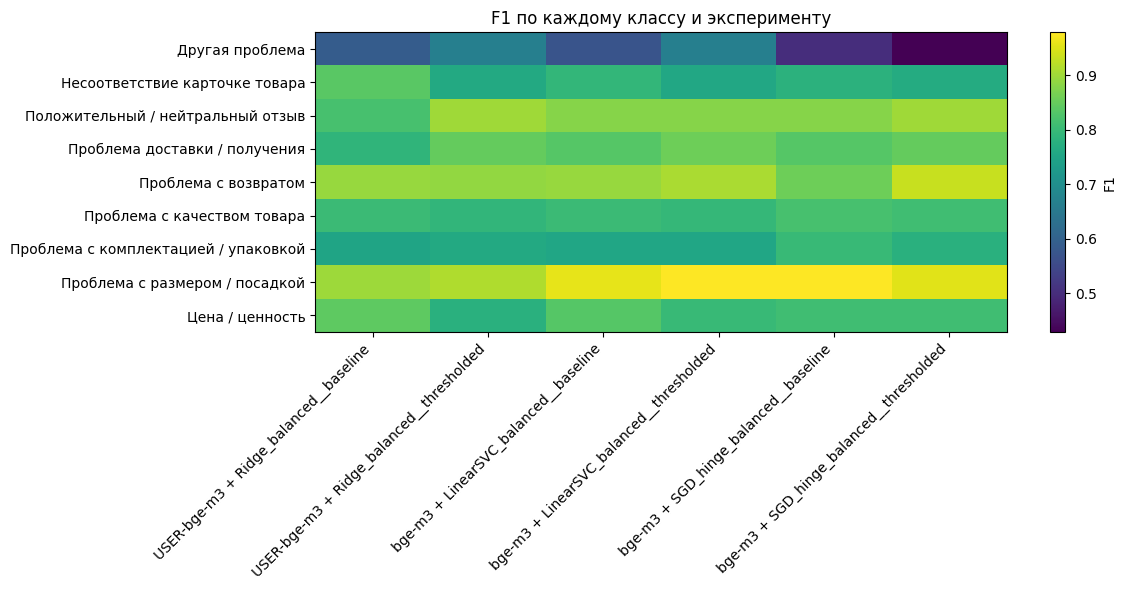

In [21]:
# График 3: heatmap F1 по классам и экспериментам.
# Чем светлее/темнее цвет — тем выше/ниже F1. Конкретная цветовая схема не задается.
heatmap_df = f1_pivot.copy().fillna(0)

plt.figure(figsize=(max(12, 0.9 * heatmap_df.shape[1]), max(6, 0.45 * heatmap_df.shape[0])))
plt.imshow(heatmap_df.values, aspect="auto")
plt.colorbar(label="F1")
plt.xticks(np.arange(heatmap_df.shape[1]), heatmap_df.columns, rotation=45, ha="right")
plt.yticks(np.arange(heatmap_df.shape[0]), heatmap_df.index)
plt.title("F1 по каждому классу и эксперименту")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "per_class_f1_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

Лучший эксперимент: bge-m3 + LinearSVC_balanced__thresholded


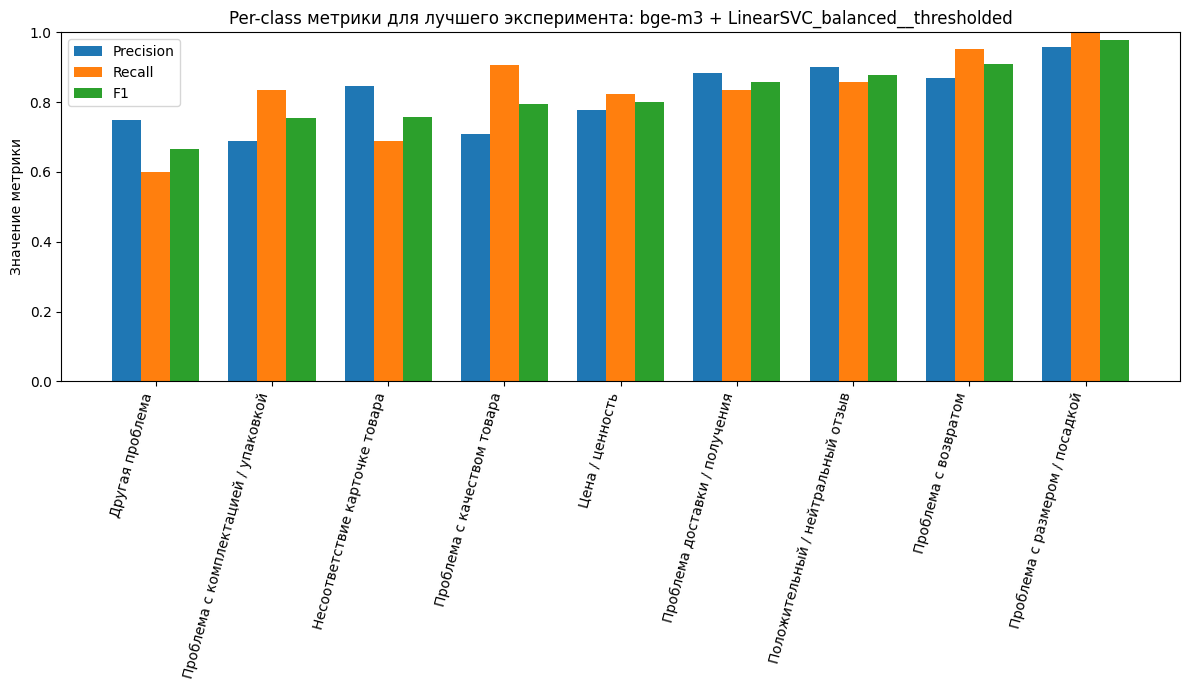

,embedding_model,classifier,class,precision,recall,f1,support,true_rate_golden,predicted_rate_golden,best_threshold,oof_f1_at_threshold,support_train,true_rate_train,predicted_rate_oof_at_threshold,experiment
27,bge-m3,LinearSVC_balanced__thresholded,Другая проблема,0.750000,0.600000,0.666667,5,0.034014,0.027211,0.288655,0.493506,66.0,0.038084,0.050779,bge-m3 + LinearSVC_balanced__thresholded
33,bge-m3,LinearSVC_balanced__thresholded,Проблема с комплектацией / упаковкой,0.689655,0.833333,0.754717,24,0.163265,0.197279,0.018063,0.809735,421.0,0.242931,0.278707,bge-m3 + LinearSVC_balanced__thresholded
28,bge-m3,LinearSVC_balanced__thresholded,Несоответствие карточке товара,0.846154,0.687500,0.758621,32,0.217687,0.176871,0.268299,0.735632,231.0,0.133295,0.117715,bge-m3 + LinearSVC_balanced__thresholded
32,bge-m3,LinearSVC_balanced__thresholded,Проблема с качеством товара,0.709091,0.906977,0.795918,43,0.292517,0.374150,-0.028527,0.799062,598.0,0.345066,0.392960,bge-m3 + LinearSVC_balanced__thresholded
35,bge-m3,LinearSVC_balanced__thresholded,Цена / ценность,0.777778,0.823529,0.800000,17,0.115646,0.122449,0.048098,0.870712,183.0,0.105597,0.113099,bge-m3 + LinearSVC_balanced__thresholded
30,bge-m3,LinearSVC_balanced__thresholded,Проблема доставки / получения,0.882353,0.833333,0.857143,18,0.122449,0.115646,0.377281,0.785146,205.0,0.118292,0.099250,bge-m3 + LinearSVC_balanced__thresholded
29,bge-m3,LinearSVC_balanced__thresholded,Положительный / нейтральный отзыв,0.900000,0.857143,0.878049,21,0.142857,0.136054,0.252859,0.857143,201.0,0.115984,0.106174,bge-m3 + LinearSVC_balanced__thresholded
31,bge-m3,LinearSVC_balanced__thresholded,Проблема с возвратом,0.869565,0.952381,0.909091,21,0.142857,0.156463,0.201247,0.830108,230.0,0.132718,0.135603,bge-m3 + LinearSVC_balanced__thresholded
34,bge-m3,LinearSVC_balanced__thresholded,Проблема с размером / посадкой,0.958333,1.000000,0.978723,23,0.156463,0.163265,0.184689,0.810811,210.0,0.121177,0.113676,bge-m3 + LinearSVC_balanced__thresholded


In [22]:
# График 4: precision/recall/F1 по классам для лучшего эксперимента.
best = summary_metrics_sorted.iloc[0]
best_model = best["embedding_model"]
best_classifier = best["classifier"]
print("Лучший эксперимент:", best_model, "+", best_classifier)

best_per_class = per_class_metrics[
    (per_class_metrics["embedding_model"] == best_model) &
    (per_class_metrics["classifier"] == best_classifier)
].copy().sort_values("f1", ascending=True)

x = np.arange(len(best_per_class))
width = 0.25

plt.figure(figsize=(max(12, 0.65 * len(best_per_class)), 7))
plt.bar(x - width, best_per_class["precision"], width, label="Precision")
plt.bar(x, best_per_class["recall"], width, label="Recall")
plt.bar(x + width, best_per_class["f1"], width, label="F1")
plt.xticks(x, best_per_class["class"], rotation=75, ha="right")
plt.ylim(0, 1)
plt.ylabel("Значение метрики")
plt.title(f"Per-class метрики для лучшего эксперимента: {best_model} + {best_classifier}")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "best_experiment_per_class_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

best_per_class

## 8. Где сохранены результаты

Новые файлы сохраняются отдельно, чтобы не путать их с большим прогоном всех моделей.


In [23]:
print("Baseline summary:", OUTPUT_DIR / "summary_metrics_selected_baseline.csv")
print("Baseline per-class:", OUTPUT_DIR / "per_class_metrics_selected_baseline.csv")
print("Thresholded summary:", OUTPUT_DIR / "summary_metrics_selected_thresholded.csv")
print("Thresholded per-class:", OUTPUT_DIR / "per_class_metrics_selected_thresholded.csv")
print("Combined summary:", OUTPUT_DIR / "summary_metrics_selected_combined.csv")
print("Combined per-class:", OUTPUT_DIR / "per_class_metrics_selected_combined.csv")
print("Threshold CSV files:", OUTPUT_DIR / "<model>__<classifier>__thresholds.csv")
print("Кеш embeddings:", EMB_DIR)
print("Обученные классификаторы:", MODEL_DIR)
print("Графики:", PLOTS_DIR)


Baseline summary: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/summary_metrics_selected_baseline.csv
Baseline per-class: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/per_class_metrics_selected_baseline.csv
Thresholded summary: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/summary_metrics_selected_thresholded.csv
Thresholded per-class: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/per_class_metrics_selected_thresholded.csv
Combined summary: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/summary_metrics_selected_combined.csv
Combined per-class: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/per_class_metrics_selected_combined.csv
Threshold CSV files: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_class

## 9. Как читать результат

Главная таблица — `summary_metrics_sorted`.

Сначала смотри:

- `macro_f1` — насколько модель в среднем хорошо работает по всем классам;
- `macro_recall` — насколько хорошо она находит проблемы каждого класса;
- `macro_precision` — насколько редко она ошибочно ставит лишние классы.

Потом обязательно смотри `best_per_class`: там видно, какие классы модель проваливает. Обычно самые проблемные пары:

- брак / низкое качество материала;
- упаковка / доставка;
- несоответствие описанию / несоответствие ожиданиям;
- цена / просто упоминание цены;
- положительный или нейтральный отзыв / скрытая жалоба.

Если какой-то класс имеет низкий recall, значит модель часто его пропускает. Если низкий precision, значит модель слишком часто ставит этот класс ошибочно.